## Set up data and model objects

In [55]:
import pandas as pd
import numpy as np
import os

import mudata as md
import anndata as ad
import perturbo
import seaborn as sns
import pyro
from scipy.stats import norm
import matplotlib.pyplot as plt
import torch
import scvi

scvi.settings.seed = 0

Global seed set to 0


Set training configuration and access to data

In [56]:
data_dir = "/work/data/SHARED_DATA/gasperini_2019/gasperini_atscale/"
batch_size=2048

# smoke_test=True # only run a tiny subset of genes
smoke_test=False # run full analysis

if torch.cuda.is_available():
    accelerator = "gpu"
    print("training using GPU")
else:
    accelerator = "cpu"
    print("training using CPU")

training using GPU


In [58]:
os.listdir(data_dir)

['mmc2.xlsx',
 '._mmc2.xlsx',
 '.DS_Store',
 '._.DS_Store',
 'mmc4.xlsx',
 '._mmc4.xlsx',
 'GSE120861_at_scale_screen_chunk.h5mu',
 '._~$mmc2.xlsx',
 'GSE120861_at_scale_screen.cells.txt.gz',
 'GSE120861_at_scale_screen.genes.txt.gz',
 'GSE120861_at_scale_screen.phenoData.txt.gz',
 'GSE120861_gene_gRNAgroup_pair_table.at_scale.txt.gz',
 'GSE120861_grna_groups.at_scale.txt.gz',
 'GSE120861_at_scale_screen.exprs.mtx.gz',
 'GSE120861_at_scale_screen_chunk.00.umi_counts.png',
 'GSE120861_at_scale_screen.cds.rds',
 '.ipynb_checkpoints',
 'process_data.R',
 'GSE120861_at_scale_screen.covariates.csv.gz',
 'cols.txt',
 'GSE120861_at_scale_screen.h5mu',
 'GSE120861_at_scale_screen_chunk.00.h5mu',
 'GSE120861_at_scale_screen_chunk.01.h5mu',
 'GSE120861_at_scale_screen_chunk.02.h5mu',
 'GSE120861_at_scale_screen_chunk.03.h5mu',
 'GSE120861_at_scale_screen_chunk.04.h5mu',
 'GSE120861_at_scale_screen_chunk.00.results.csv.gz']

In [3]:
chunk_number = 0
mdata_file = f"{data_dir}/GSE120861_at_scale_screen_chunk.{chunk_number:02d}.h5mu"
mdata_all = md.read_h5mu(mdata_file)
mdata_all

MuData object with n_obs × n_vars = 207324 × 6631
  2 modalities
    rna:	207324 x 3000
      obs:	'sample', 'total_umis', 'Size_Factor', 'read_count', 'umi_count', 'proportion', 'guide_count', 'id', 'prep_batch', 'within_batch_chip', 'within_chip_lane', 'percent.mito'
      var:	'gene_name', 'contig', 'start', 'end'
    grna:	207324 x 3631
      var:	'Spacer', 'Target_Site', 'chr.candidate_enhancer', 'start.candidate_enhancer', 'stop.candidate_enhancer', 'Category', 'element'
      uns:	'elements'
      varm:	'element_targeted'

### Load the data
(50k cells, takes ~30 seconds)

207324

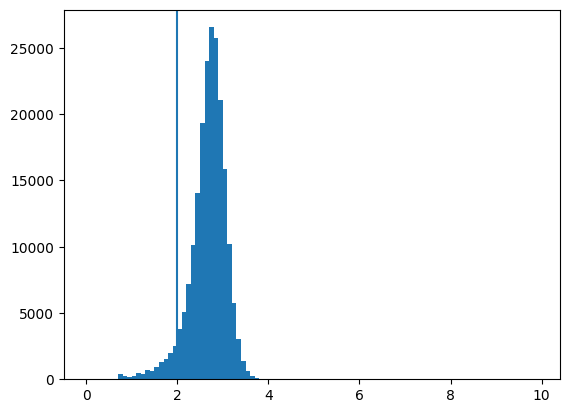

In [4]:
plt.hist(np.log10(mdata_all['rna'].obs['umi_count']), bins = np.arange(0,10,0.1))
plt.axvline(2.0)
selected_cells = mdata_all['rna'].obs['umi_count']>100
plt.savefig(mdata_file.replace("h5mu", "umi_counts.png"))
len(selected_cells)
# np.mean()

In [5]:
# log_mean_counts_per_cell = np.log10(mdata_all['rna'].X.sum(axis=0).A1)
# mean_counts_per_cell = mdata_all['rna'].X.sum(axis=0).A1
# plt.hist(mean_counts_per_cell)

In [6]:
# selected_guides = mdata_all['grna'].var.index
# !ls /work/data
sceptre_results = pd.read_csv("/work/data/SHARED_DATA/gasperini_2019/all_results.csv")
sceptre_results

,gene_id,gRNA_id,p_value,skew_t_fit_success,xi,omega,alpha,nu
0,ENSG00000008256,ACTB_TSS,1.684303e-01,True,-0.066602,0.947855,0.126446,3.946003e+01
1,ENSG00000011275,ACTB_TSS,2.010234e-01,True,-0.553322,1.085214,0.737834,8.256523e+01
2,ENSG00000075618,ACTB_TSS,9.916670e-01,True,-0.916371,1.312246,0.889398,1.107978e+03
3,ENSG00000075624,ACTB_TSS,5.007100e-11,True,-0.866612,1.783860,0.968370,9.667537e+04
4,ENSG00000086232,ACTB_TSS,2.941922e-01,True,0.527563,0.990631,-0.329564,1.791409e+01
...,...,...,...,...,...,...,...,...
629510,ENSG00000066827,chr8.3446_top_two,1.372567e-01,True,-0.654953,1.099360,1.043521,5.741392e+00
629511,ENSG00000131773,chr8.3446_top_two,1.267156e-01,True,-1.078687,1.427121,3.831266,1.427994e+07
629512,ENSG00000022567,chr8.3533_top_two,4.683269e-01,True,-0.159764,0.940689,0.175429,2.627980e+01
629513,ENSG00000104472,chr8.3533_top_two,1.477046e-01,False,NaN,NaN,NaN,NaN


In [7]:
selected_genes = mdata_all['rna'].var_names

# chunk_size=5000
# selected_genes = mdata_all['rna'].var_names[:chunk_size]
# selected_genes = mdata_all['rna'].var_names[log_mean_counts_per_cell > -3]
# selected_genes = sceptre_results['gene_id'].unique()
selected_genes
# len(selected_genes)

Index(['ENSG00000238009', 'ENSG00000237683', 'ENSG00000228463',
       'ENSG00000237094', 'ENSG00000235373', 'ENSG00000228327',
       'ENSG00000237491', 'ENSG00000225880', 'ENSG00000230368',
       'ENSG00000188976',
       ...
       'ENSG00000123933', 'ENSG00000159733', 'ENSG00000063978',
       'ENSG00000125386', 'ENSG00000168884', 'ENSG00000087266',
       'ENSG00000087274', 'ENSG00000109736', 'ENSG00000249673',
       'ENSG00000087269'],
      dtype='object', name='gene_id', length=3000)

In [8]:
selected_guides = mdata_all['grna'].var.query('Category=="NTC" or Category=="TSS"').index
selected_guides

Index(['AATGAGGAGCAAACGAAAAT', 'ACGAAATGTTTCATGACCAA', 'ATAGATTTACGTTACTCTCT',
       'ATTAGCATCAGGTAGACTAA', 'CCATAAAGAATTCGGTGTAG', 'CGAAAATGGGTGCGTGGACT',
       'CGAAGGATCAAAGCGACTTT', 'CGTATTTCTCTTAGAGATCA', 'GAGAAAAGTCGTTCTACAAA',
       'GCGTCCCTAGGGTATTTTAC',
       ...
       'ACAGTAGCTACAGCCCCGGG', 'GCAGAAGCGGCAGGAGTAGG', 'AGTGGTGGGACTCGCGTCGG',
       'CGCGGCCGCGGAGACGTGAG', 'TCCAGAAGAAACTAAGAGGG', 'TCCGGGTTGTCACTCTCTCG',
       'AACAGCCCGGCCGGCCAAGG', 'TCGGTGCGCGCCTGTCCGGG', 'CCCGCAGCTATGTCTTCACG',
       'GGCGCCATAAGGACAACCCG'],
      dtype='object', name='guide', length=311)

In [9]:
mdata_subset = mdata_all[selected_cells,:]

# subset to desired grnas/elements
grna_subset = mdata_subset.mod['grna'][:,selected_guides].copy()
selected_element_idx = np.where(grna_subset.varm['element_targeted'].sum(axis=0)>0)[0]
selected_elements = grna_subset.uns['elements'][selected_element_idx]
grna_subset.varm['element_targeted'] = grna_subset.varm['element_targeted'][:,selected_element_idx]
grna_subset.uns['elements']=selected_elements

# subset to desired genes
rna_subset = mdata_subset.mod['rna'][:,selected_genes].copy()
mdata = md.MuData({'rna':rna_subset, 'grna':grna_subset})
mdata

MuData object with n_obs × n_vars = 193951 × 3311
  2 modalities
    rna:	193951 x 3000
      obs:	'sample', 'total_umis', 'Size_Factor', 'read_count', 'umi_count', 'proportion', 'guide_count', 'id', 'prep_batch', 'within_batch_chip', 'within_chip_lane', 'percent.mito'
      var:	'gene_name', 'contig', 'start', 'end'
    grna:	193951 x 311
      var:	'Spacer', 'Target_Site', 'chr.candidate_enhancer', 'start.candidate_enhancer', 'stop.candidate_enhancer', 'Category', 'element'
      uns:	'elements'
      varm:	'element_targeted'

check to make sure we properly subset the element labels in the .uns field

In [10]:
assert len(grna_subset.uns['elements']) == mdata['grna'].varm['element_targeted'].shape[1]

## Register data with perturbo

In [11]:
perturbo.PERTURBO.setup_mudata(
    mdata,
    batch_key="prep_batch",
    library_size_key="umi_count",
    continuous_covariates_keys=["percent.mito", "Size_Factor"],
    # var_by_element_key="element_tested",
    perturb_by_element_key="element_targeted",
    modalities={
        "rna_layer": "rna",
        "perturbation_layer": "grna",
    },
)

model = perturbo.PERTURBO(mdata, likelihood='lnnb', fit_lib_size=False, fit_dispersion=False)
model.view_anndata_setup()


No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


INFO     Generating sequential column names                                                                        


Anndata setup with scvi-tools version 1.0.2.

Setup via `PERTURBO.setup_anndata` with arguments:

{
│   'rna_layer': None,
│   'perturbation_layer': None,
│   'batch_key': 'prep_batch',
│   'var_by_element_key': None,
│   'perturb_by_element_key': 'element_targeted',
│   'library_size_key': 'umi_count',
│   'size_factor_key': None,
│   'continuous_covariates_keys': ['percent.mito', 'Size_Factor'],
│   'categorical_covariates_keys': None,
│   'modalities': {'rna_layer': 'rna', 'perturbation_layer': 'grna'}
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃    Summary Stat Key     ┃ Value  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│         n_batch         │   2    │
│         n_cells         │ 193951 │
│ n_extra_continuous_covs │   2    │
│     n_perturbations     │  311   │
│   n_targeted_elements   │  156   │
│         n_vars          │  3000  │
└─────────────────────────┴────────┘

                                 Data Registry                                  
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃     Registry Key      ┃                 scvi-tools Location                  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│           X           │                  adata.mod['rna'].X                  │
│         batch         │         adata.mod['rna'].obs['_scvi_batch']          │
│ extra_continuous_covs │ adata.mod['rna'].obsm['_scvi_extra_continuous_covs'] │
│         ind_x         │            adata.mod['rna'].obs['_ind_x']            │
│     perturbations     │                 adata.mod['grna'].X                  │
│      size_factor      │         adata.mod['rna'].obs['_size_factor']         │
│   targeted_elements   │      adata.mod['grna'].varm['element_targeted']      │
└───────────────────────┴──────────────────────────────────────────────────────┘

                      batch State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location     ┃  Categories  ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['prep_batch'] │ prep_batch_1 │          0          │
│                         │ prep_batch_2 │          1          │
└─────────────────────────┴──────────────┴─────────────────────┘

 extra_continuous_covs State 
          Registry           
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['percent.mito'] │
│ adata.obs['Size_Factor']  │
└───────────────────────────┘

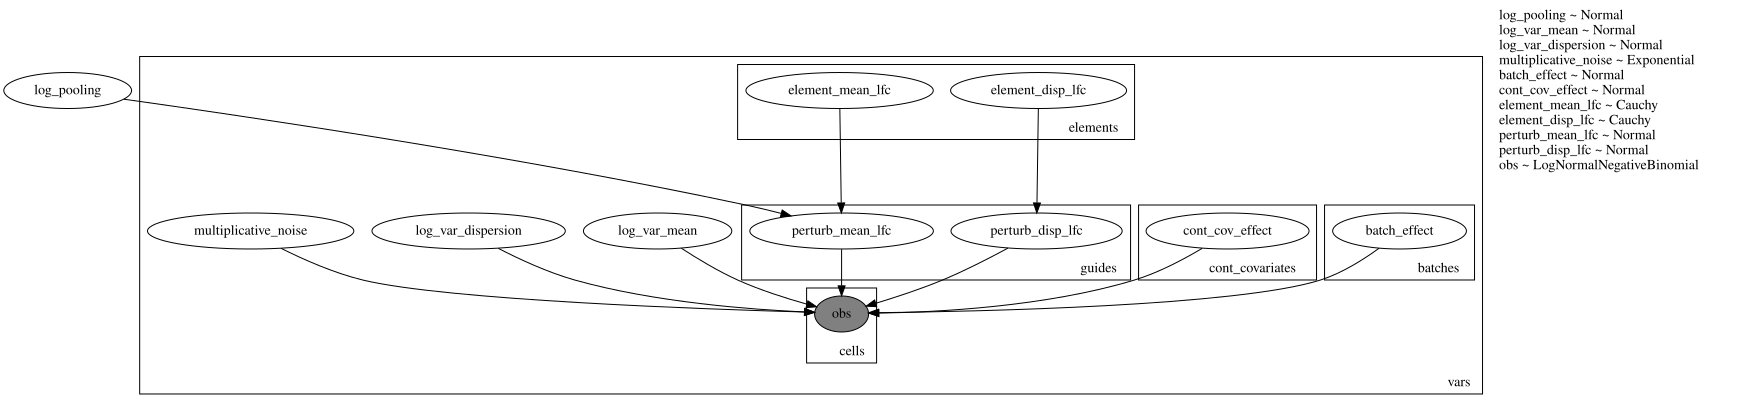

In [12]:
# requires graphviz to be installed
model.render_model()

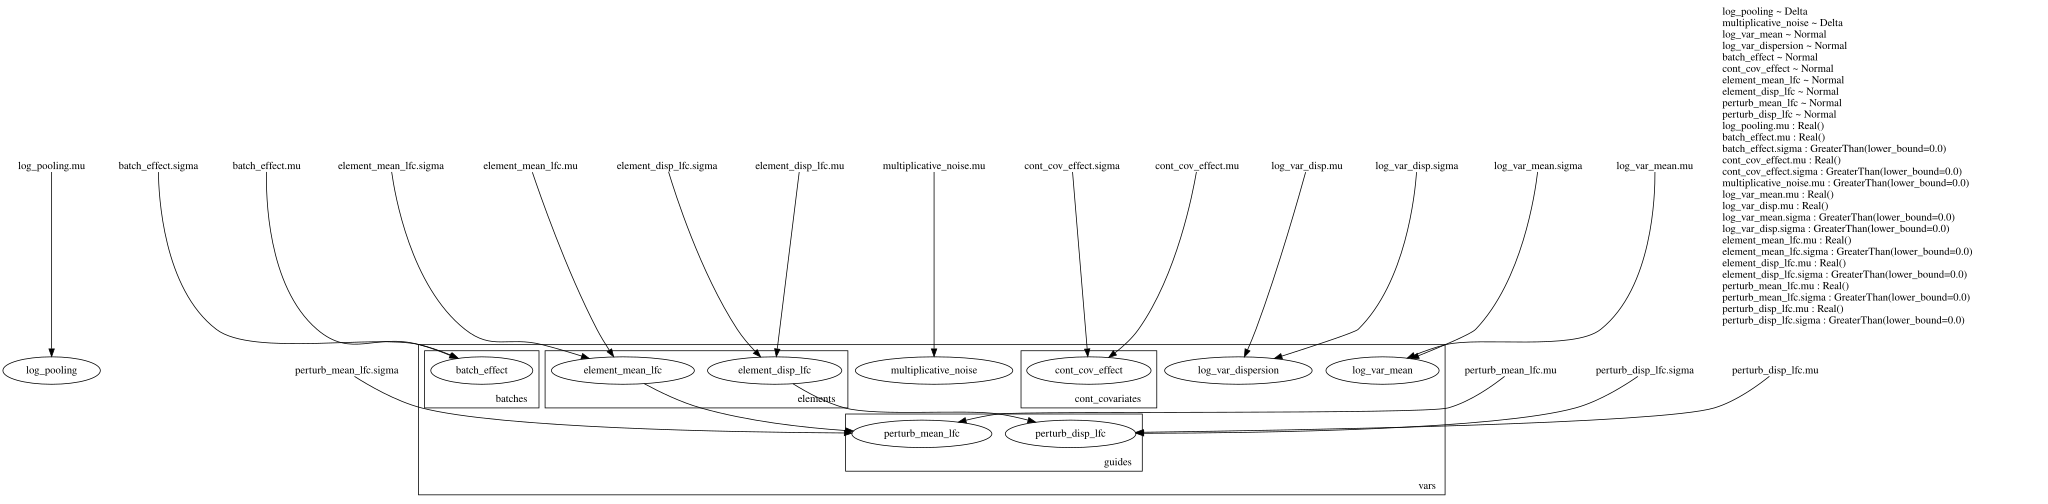

In [13]:
model.render_guide()

### Train the model

In [14]:
# burn-in
pyro.clear_param_store()
# plan_kwargs = {'optim': pyro.optim.ClippedAdam(dict(lr=0.1, lrd=0.96))}
# model.train(20, lr=0.05, batch_size=512, use_gpu=use_gpu)
# model.train(20, lr=0.05, batch_size=512, use_gpu=use_gpu)


In [15]:
## fine-tune
# plan_kwargs = {'optim': pyro.optim.ClippedAdam(dict(lr=0.1, lrd=0.99))}
# model.train(20, lr=0.1, batch_size=1024, use_gpu=use_gpu)
# model.train(100, lr=0.03, batch_size=1024, use_gpu=use_gpu)
pyro.get_param_store().keys()

dict_keys([])

In [16]:
for k, v in pyro.get_param_store().items():
    if (~torch.isreal(v)).any():
        print(k)


In [17]:
model.train(20, lr=0.01, batch_size=batch_size, accelerator=accelerator) 

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/usr/local/lib/python3.10/dist-packages/lightning/pytorch/trainer/configuration_validator.py:68: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 20/20: 100%|██████████| 20/20 [03:25<00:00, 10.19s/it, v_num=1, elbo_train=4.33e+8]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 20/20: 100%|██████████| 20/20 [03:25<00:00, 10.28s/it, v_num=1, elbo_train=4.33e+8]


In [18]:
model.train(10, lr=0.001, batch_size=batch_size, accelerator=accelerator)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/usr/local/lib/python3.10/dist-packages/lightning/pytorch/trainer/configuration_validator.py:68: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 10/10: 100%|██████████| 10/10 [01:41<00:00, 10.32s/it, v_num=1, elbo_train=4.29e+8]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 10/10: 100%|██████████| 10/10 [01:41<00:00, 10.18s/it, v_num=1, elbo_train=4.29e+8]


In [19]:
from scipy.stats import chi2

variance_eqtl = False

# compute "q-value" based on 1 - maximum posterior CI which overlaps zero
q_mu, q_sigma = model.module.get_element_effects()
assert q_mu.shape == q_sigma.shape
perturb_z_scores = q_mu/q_sigma
perturb_p_vals=chi2.sf((perturb_z_scores)**2, df=1)

In [20]:
def make_long_df(mat, value_name):
    return (
        pd.DataFrame(data=mat, index=mdata['grna'].uns['elements'], columns=mdata['rna'].var['gene_name'])
        .melt(var_name="gene", value_name=value_name, ignore_index=False)
        .reset_index(names="element")
    )

scpower_df = pd.merge(
    make_long_df(perturb_z_scores, "z_value"),
    make_long_df(perturb_p_vals, "p_value")
)

results_file = mdata_file.replace("h5mu", "results.csv.gz")
print(f"Writing test results to {results_file}")
scpower_df.to_csv(results_file)


Writing test results to /work/data/SHARED_DATA/gasperini_2019/gasperini_atscale//GSE120861_at_scale_screen_chunk.00.results.csv.gz


In [21]:
# model.save("gasperini_atscale_model.save", overwrite=True)

In [22]:
for k, v in pyro.get_param_store().items():
    print(k, v.shape)
    if sum(v.shape) <= 5:
        print(v)

log_pooling.mu torch.Size([1])
tensor([-2.3540], device='cuda:0', requires_grad=True)
batch_effect.mu torch.Size([2, 3000])
batch_effect.sigma torch.Size([2, 3000])
cont_cov_effect.mu torch.Size([3, 3000])
cont_cov_effect.sigma torch.Size([3, 3000])
multiplicative_noise.mu torch.Size([3000])
log_var_mean.mu torch.Size([3000])
log_var_disp.mu torch.Size([3000])
log_var_mean.sigma torch.Size([3000])
log_var_disp.sigma torch.Size([3000])
element_mean_lfc.mu torch.Size([156, 3000])
element_mean_lfc.sigma torch.Size([156, 3000])
element_disp_lfc.mu torch.Size([156, 3000])
element_disp_lfc.sigma torch.Size([156, 3000])
perturb_mean_lfc.mu torch.Size([311, 3000])
perturb_mean_lfc.sigma torch.Size([311, 3000])
perturb_disp_lfc.mu torch.Size([311, 3000])
perturb_disp_lfc.sigma torch.Size([311, 3000])


In [23]:
# store["cont_cov_effect.mu"][2,:].shape

In [24]:
# scpower_df.to_csv(f"{data_dir}/scpower_results.csv")
store = pyro.get_param_store()
gene_mean = store["log_var_mean.mu"].detach().cpu().numpy()
gene_disp = store["log_var_disp.mu"].detach().cpu().numpy()
if "multiplicative_noise.mu" in store:
    gene_noise = store["multiplicative_noise.mu"].detach().cpu().numpy()

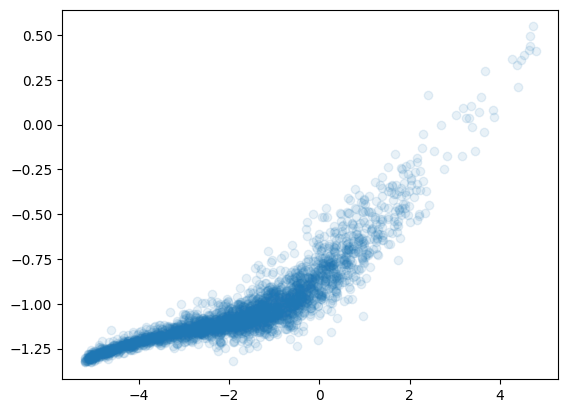

In [25]:
empirical_gene_mean = mdata['rna'].X.mean(axis=0).A1
empirical_lib_size = mdata['rna'].X.sum(axis=1).mean()
# plt.scatter(np.log(), gene_mean, alpha=0.1)
plt.scatter(np.log(empirical_gene_mean), gene_mean, alpha=0.1)
# plt.scatter(np.log(mdata['rna'].X.mean(axis=0).A1), store["cont_cov_effect.mu"][2,:].detach().cpu().numpy(), alpha=0.1)


Text(0.5, 1.0, 'mean vs. dispersion')

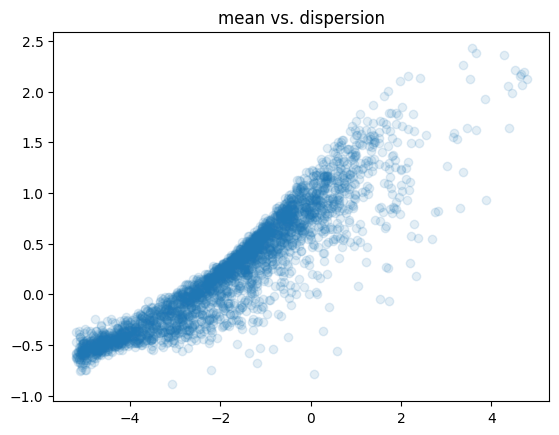

In [26]:
plt.scatter(
    np.log(empirical_gene_mean),
    gene_disp,
    alpha=0.12,
)
plt.title("mean vs. dispersion")

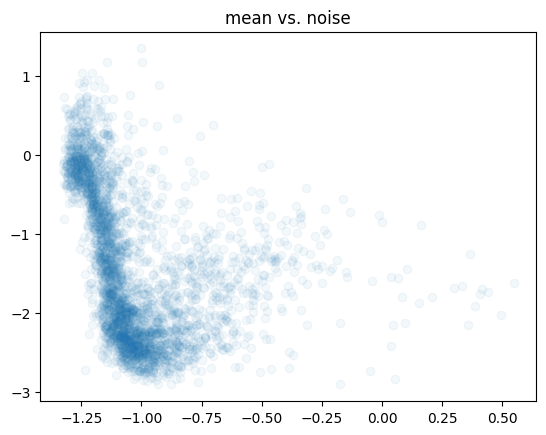

In [27]:
if "multiplicative_noise.mu" in store:
    plt.scatter(
        gene_mean,
        np.log(gene_noise),
        alpha=0.05,
    )
    plt.title("mean vs. noise")

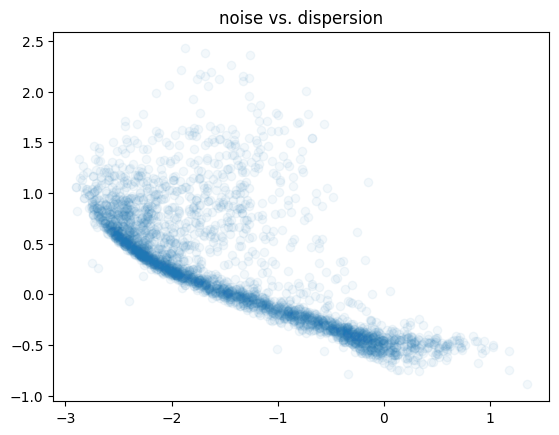

In [28]:
if "multiplicative_noise.mu" in store:

    plt.scatter(
        np.log(gene_noise),
        gene_disp,
        alpha=0.05
    )
    plt.title("noise vs. dispersion")

In [29]:
print(np.min(perturb_p_vals))
print(np.max(perturb_p_vals))

5.257120089610424e-116
0.9999991929748913


In [30]:
np.isnan(perturb_z_scores).any()

False

In [31]:
len(mdata['grna'].uns['elements'])

156

convert matrix into long df of results

In [32]:
scpower_df

,element,gene,z_value,p_value
0,ADIPOR1_TSS,RP11-34P13.7,0.958885,0.337617
1,ARID1A_TSS,RP11-34P13.7,-0.032535,0.974046
2,ARL5A_TSS,RP11-34P13.7,0.174397,0.861554
3,ARV1_TSS,RP11-34P13.7,-0.054958,0.956172
4,ATP5F1_TSS,RP11-34P13.7,0.237053,0.812616
...,...,...,...,...
468307,scrambled_5,NOP14,-0.326524,0.744028
468308,scrambled_6,NOP14,-0.091008,0.927487
468309,scrambled_7,NOP14,-0.292237,0.770105
468310,scrambled_8,NOP14,-0.662761,0.507483


In [33]:
# get the true target info
target_pair_df = mdata['grna'].var.value_counts(['element', 'Target_Site']).reset_index().set_index('element')
# target_pair_df = mdata['grna'].var.query('Category=="TSS"').value_counts(['element', 'Target_Site']).reset_index().set_index('element')
target_pair_df

,Target_Site,count
element,,
ADIPOR1_TSS,ADIPOR1,2
UAP1_TSS,UAP1,2
TAF12_TSS,TAF12,2
TFRC_TSS,TFRC,2
TIPRL_TSS,TIPRL,2
...,...,...
random_19,originalIDTorder:2,1
random_18,randomregion,1
random_18,originalIDTorder:1,1


In [34]:
# subset down to tss guides
merge_df = target_pair_df.merge(scpower_df, on='element', how='right')
merge_df = merge_df.sort_values('p_value', ascending=True)
merge_df

,element,Target_Site,count,gene,z_value,p_value
491312,SSR3_TSS,SSR3,2,SSR3,-22.894615,5.257120e-116
17030,PARK7_TSS,PARK7,2,PARK7,-21.876833,4.318072e-106
124079,ATP5F1_TSS,ATP5F1,2,ATP5F1,-21.737667,9.037654e-105
46603,NUDC_TSS,NUDC,2,NUDC,-20.273575,2.200763e-91
426033,SMARCC1_TSS,SMARCC1,2,SMARCC1,-19.197281,3.899821e-82
...,...,...,...,...,...,...
435856,random_1,randomregion,2,HYAL2,0.000002,9.999984e-01
65993,CRIPT_TSS,CRIPT,2,YRDC,-0.000002,9.999984e-01
24363,LRIF1_TSS,LRIF1,2,MIIP,0.000002,9.999985e-01
246710,random_6,randomregion,2,RRM2,-0.000002,9.999987e-01


In [35]:
merge_df=merge_df.assign(is_target=lambda x: x['Target_Site']==x['gene'])
# merge_df=merge_df.assign(is_target=lambda x: x['Target_Site']==x['gene'])


In [36]:
target_genes = mdata['grna'].var.query('Category=="TSS"')['Target_Site'].unique()
ntc_gene_labels=mdata['grna'].var.query('Category=="NTC"')['Target_Site'].unique()
ntc_gene_labels

['control', 'cag_promoter', 'non-targeting', 'originalIDTorder:1', 'originalIDTorder:2', ..., 'originalIDTorder:6', 'originalIDTorder:7', 'originalIDTorder:8', 'originalIDTorder:9', 'randomregion']
Length: 12
Categories (117, object): ['ADIPOR1', 'ARID1A', 'ARL5A', 'ARV1', ..., 'originalIDTorder:7', 'originalIDTorder:8', 'originalIDTorder:9', 'randomregion']

## Visualize hits



<Axes: xlabel='z_value', ylabel='Density'>

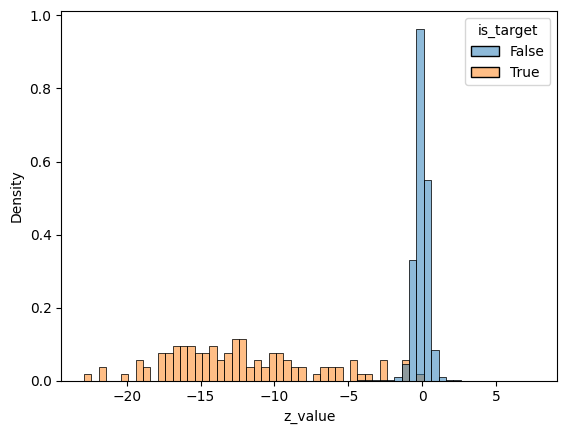

In [37]:
sns.histplot(merge_df, x='z_value', hue='is_target', common_norm=False, stat="density", binwidth=0.5)
# from sklearn.linear_model import LinearRegression

# reg_x=(merge_df[["z_value"]].values)
# reg_y=(merge_df[["SCEPTRE_z_value"]].values)
# reg = LinearRegression(fit_intercept=False).fit(reg_x, reg_y)
# print("slope:", reg.coef_[0,0])
# print("R^2:", reg.score(reg_x, reg_y))


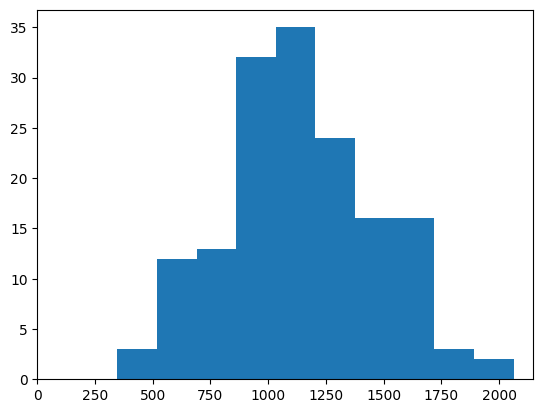

In [38]:
element_counts = (mdata['grna'].X @ mdata['grna'].varm['element_targeted']).sum(axis=0)
plt.hist(element_counts)
plt.xlim(0,None)

element_count_df = pd.DataFrame({'element':mdata['grna'].uns['elements'], 'cells':element_counts})


(array([356., 323., 480., 648., 624., 360., 139.,  45.,  13.,  12.]),
 array([-2.25830936, -1.82452083, -1.39073229, -0.95694375, -0.52315521,
        -0.08936667,  0.34442186,  0.7782104 ,  1.21199894,  1.64578748,
         2.07957602]),
 <BarContainer object of 10 artists>)

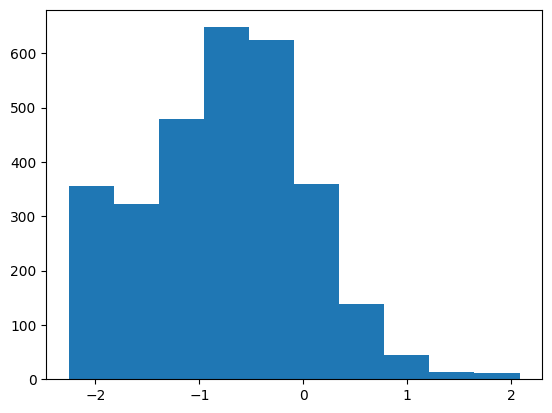

In [39]:
# mdata['rna'].var.assign(mean_expr = mdata['rna'].X.mean(axis=0))
mdata['rna'].var=mdata['rna'].var.assign(log10_mean_expression=np.log10(empirical_gene_mean))
plt.hist(mdata['rna'].var['log10_mean_expression'])

(array([1188.,  476.,  346.,  242.,  197.,  139.,  126.,   97.,   78.,
         111.]),
 array([0.00528484, 0.10475584, 0.20422684, 0.30369784, 0.40316884,
        0.50263984, 0.60211084, 0.70158184, 0.80105284, 0.90052384,
        0.99999484]),
 <BarContainer object of 10 artists>)

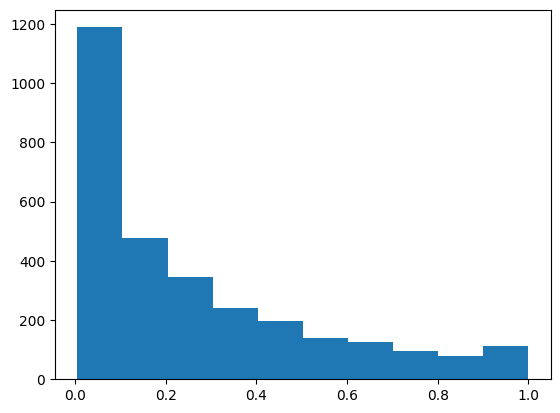

In [40]:
frac_expressed = (mdata['rna'].X>0).mean(axis=0).A1
mdata['rna'].var=mdata['rna'].var.assign(frac_expressed=frac_expressed)
plt.hist(frac_expressed)

In [41]:
# pd.read_excel(f"{data_dir}/mmc2.xlsx", sheet_name=2)
# sns.scatterplot(merge_df, x='SCEPTRE_z_value', y='SCEPTRE_p_value', hue='pair_type', alpha=0.3)

In [42]:
# plt.title("z-value comparison")
# sns.scatterplot(merge_df, x='z_value', y='SCEPTRE_z_value', hue='pair_type', alpha=0.3, palette='Set1')
# plt.axline((0, 0), slope=1, c='black', linestyle='dashed')
# plt.show()


## Interactive data visualization
Need to subset and clip the data so that we can plot interactively

In [43]:
# min_p_value = 1e-20
# merge_df['p_value'] = np.maximum(merge_df['p_value'], min_p_value)

# sns.scatterplot(merge_df, x="p_value", y="SCEPTRE_p_value", hue="pair_type", alpha=0.3, palette="Set1")
# # plt.axline((0, 0), slope=1, c='black', linestyle='dashed')
# plt.axhline(1e-4, c='black', linestyle='dashed')
# plt.axvline(1e-4,  c='black', linestyle='dashed')

# plt.loglog()
# # plt.legend()
# plt.xlim(1e-21, 2)
# plt.ylim(1e-21, 2)
# plt.hist(mdata['rna'][:,mdata['rna'].var["gene_name"]=="SPR"].X.todense())


In [44]:
neg_controls = merge_df[merge_df['Target_Site'].isin(ntc_gene_labels)]
neg_controls = neg_controls.sort_values('p_value').assign(quantile = lambda x: np.linspace(0,1, num=len(x)))
neg_controls.query("p_value<0.05")

,element,Target_Site,count,gene,z_value,p_value,is_target,quantile
227964,random_17,randomregion,2,FAM89A,-4.537087,0.000006,False,0.000000
78540,scrambled_10,non-targeting,2,CCDC24,-2.936194,0.003323,False,0.000005
291875,scrambled_17,control,1,SPR,-2.786838,0.005323,False,0.000010
291874,scrambled_17,non-targeting,1,SPR,-2.786838,0.005323,False,0.000014
497835,random_6,randomregion,2,NCEH1,2.750242,0.005955,False,0.000019
208943,scrambled_3,non-targeting,2,C1orf116,-2.682086,0.007316,False,0.000024
511662,random_8,randomregion,2,MUC4,-2.623154,0.008712,False,0.000029
450269,scrambled_4,non-targeting,2,CTD-2013N24.2,-2.548484,0.010819,False,0.000033
268080,scrambled_2,non-targeting,2,RMDN2,2.512608,0.011984,False,0.000038
471443,scrambled_3,non-targeting,2,SLC41A3,2.509595,0.012087,False,0.000043


In [45]:
worst_offenders = neg_controls.query("p_value<0.05")['gene'].unique()
mdata['rna'][:, mdata['rna'].var['gene_name'].isin(worst_offenders).values].var
# mdata['rna'].var['gene_name'].isin(worst_offenders).index

,gene_name,contig,start,end,log10_mean_expression,frac_expressed
gene_id,,,,,,
ENSG00000159214,CCDC24,1,44457031,44462200,-1.160728,0.064815
ENSG00000226476,RP11-776H12.1,1,61005921,61106163,-1.715294,0.018917
ENSG00000158773,USF1,1,161009041,161015767,-1.570697,0.026295
ENSG00000143153,ATP1B1,1,169074935,169101960,-1.655446,0.020830
ENSG00000182795,C1orf116,1,207191866,207206101,-1.449420,0.033256
ENSG00000242861,RP11-285F7.2,1,226028584,226034223,-1.683691,0.020242
ENSG00000182118,FAM89A,1,231154704,231175992,0.316958,0.705420
ENSG00000077522,ACTN2,1,236849754,236927931,-1.845532,0.012807
ENSG00000115841,RMDN2,2,38150330,38294285,-1.516997,0.029456


In [46]:
element_count_df.merge(neg_controls, on="element").sort_values('p_value').head(50)
# neg_controls
# (mdata['grna'].var['element']=='random_17').values
# sns.histplot(guide_counts)
# plt.semilogy()

,element,cells,Target_Site,count,gene,z_value,p_value,is_target,quantile
27018,random_17,767.0,randomregion,2,FAM89A,-4.537087,0.000006,False,0.000000
105070,scrambled_10,1204.0,non-targeting,2,CCDC24,-2.936194,0.003323,False,0.000005
132089,scrambled_17,994.0,non-targeting,1,SPR,-2.786838,0.005323,False,0.000014
132088,scrambled_17,994.0,control,1,SPR,-2.786838,0.005323,False,0.000010
90060,random_6,1292.0,randomregion,2,NCEH1,2.750242,0.005955,False,0.000019
189126,scrambled_3,659.0,non-targeting,2,C1orf116,-2.682086,0.007316,False,0.000024
96064,random_8,750.0,randomregion,2,MUC4,-2.623154,0.008712,False,0.000029
192128,scrambled_4,1943.0,non-targeting,2,CTD-2013N24.2,-2.548484,0.010819,False,0.000033
150100,scrambled_2,1337.0,non-targeting,2,RMDN2,2.512608,0.011984,False,0.000038
189127,scrambled_3,659.0,non-targeting,2,SLC41A3,2.509595,0.012087,False,0.000043


(1, 4.758732273722281e-06)

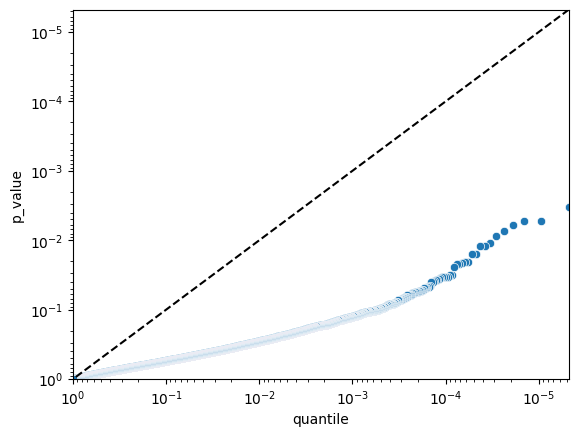

In [47]:
plt.axline((0,0), slope=1, linestyle="dashed", color="black")
# plt.scatter(np.linspace(0,1, num=len(neg_controls)), neg_controls['p_value'].sort_values())
sns.scatterplot(neg_controls, x="quantile", y='p_value')
plt.loglog()
plt.ylim(1,1/len(neg_controls))
plt.xlim(1,1/len(neg_controls))

In [48]:
pos_controls = merge_df[merge_df['Target_Site'].isin(target_genes)]
pos_controls = pos_controls.assign(quantile=lambda x: x.groupby('is_target')['p_value'].rank(pct=True))
# pos_controls=pos_controls[~pos_controls['gene'].str.contains("-AS")] # remove alt start sites
pos_controls=pos_controls.assign(
    perturbo_rank=lambda x: x.groupby('element')['p_value'].rank(),
    perturbo_p_rank=lambda x: x.groupby('element')['z_value'].rank(),
    # SCEPTRE_p_rank=lambda x: x.groupby('guide')['SCEPTRE_p_value'].rank(),
    # SCEPTRE_z_rank=lambda x: x.groupby('guide')['SCEPTRE_z_value'].rank()
)
pos_controls

,element,Target_Site,count,gene,z_value,p_value,is_target,quantile,perturbo_rank,perturbo_p_rank
491312,SSR3_TSS,SSR3,2,SSR3,-22.894615,5.257120e-116,True,0.009524,1.0,1.0
17030,PARK7_TSS,PARK7,2,PARK7,-21.876833,4.318072e-106,True,0.019048,1.0,1.0
124079,ATP5F1_TSS,ATP5F1,2,ATP5F1,-21.737667,9.037654e-105,True,0.028571,1.0,1.0
46603,NUDC_TSS,NUDC,2,NUDC,-20.273575,2.200763e-91,True,0.038095,1.0,1.0
426033,SMARCC1_TSS,SMARCC1,2,SMARCC1,-19.197281,3.899821e-82,True,0.047619,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...
382446,RNF7_TSS,RNF7,2,PSMD1,0.000004,9.999968e-01,False,0.999987,3002.0,1968.0
33312,PTP4A2_TSS,PTP4A2,2,CAMK2N1,0.000003,9.999974e-01,False,0.999990,3002.0,1614.0
65993,CRIPT_TSS,CRIPT,2,YRDC,-0.000002,9.999984e-01,False,0.999994,3002.0,1828.0
24363,LRIF1_TSS,LRIF1,2,MIIP,0.000002,9.999985e-01,False,0.999997,3002.0,1634.0


(1, 3.1724881824815203e-06)

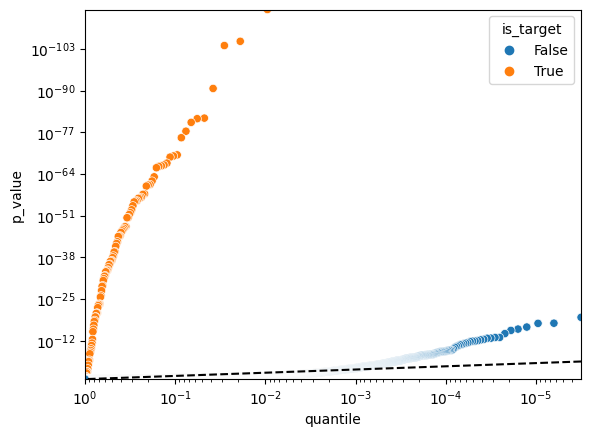

In [49]:
plt.axline((0,0), slope=1, linestyle="dashed", color="black")
sns.scatterplot(pos_controls, x="quantile", y='p_value', hue="is_target")
plt.loglog()
plt.ylim(1,pos_controls['p_value'].min())
plt.xlim(1,1/len(pos_controls))

In [50]:
sns.ecdfplot

<function seaborn.distributions.ecdfplot(data=None, *, x=None, y=None, hue=None, weights=None, stat='proportion', complementary=False, palette=None, hue_order=None, hue_norm=None, log_scale=None, legend=True, ax=None, **kwargs)>

In [51]:
target_pairs = pos_controls.query('is_target')
print("our accuracy: "+str(len(target_pairs.query('perturbo_rank==1'))/len(target_pairs)))
# print("SCEPTRE accuracy: "+str(len(target_pairs.query('SCEPTRE_z_rank==1'))/len(target_pairs)))
# print("SCEPTRE accuracy: "+str(len(target_pairs.query('SCEPTRE_p_rank==1'))/len(target_pairs)))

our accuracy: 0.9523809523809523


(0.0, 20.0)

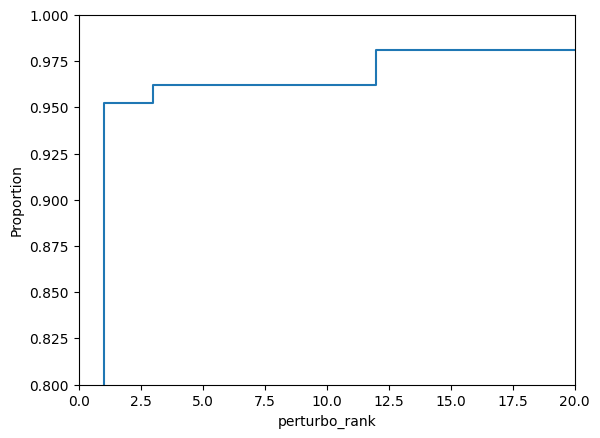

In [52]:
# with plt.rc_context({"figure.figsize": [3,3]}):
sns.ecdfplot(pos_controls.query('is_target'), x='perturbo_rank',stat="proportion", label="PerTurbo")
plt.ylim(0.8, 1)
plt.xlim([0,20])


In [53]:
# target_pairs.query('perturbo_rank==1 and SCEPTRE_z_rank>=2')[['guide','gene','perturbo_rank','SCEPTRE_p_rank']]
target_pairs.query('perturbo_rank==1 and SCEPTRE_z_rank>1')[['guide','gene','perturbo_rank','SCEPTRE_z_rank']]
# target_pairs.query('perturbo_rank>1 and SCEPTRE_p_rank==1')[['guide','gene','perturbo_rank','SCEPTRE_p_rank']]

UndefinedVariableError: name 'SCEPTRE_z_rank' is not defined

In [ ]:
target_pairs.query('perturbo_rank>1 and SCEPTRE_p_rank==1')[['guide','gene','perturbo_rank','SCEPTRE_p_rank']]

In [ ]:
with plt.rc_context({"figure.figsize": [3,3]}):

  sns.ecdfplot(pos_controls.query('is_target'), x='perturbo_rank',stat="proportion", label="PerTurbo")
  sns.ecdfplot(pos_controls.query('is_target'), x='SCEPTRE_p_rank',stat="proportion", label="SCEPTRE")
  sns.ecdfplot(pos_controls.query('is_target'), x='SCEPTRE_z_rank',stat="proportion", label="SCEPTRE_z")
  plt.legend()
  # plt.title("eCDF")
  # plt.semilogy()
  plt.xlabel("rank")
  plt.xlim([0,10])
  plt.ylim(0.8, 1)
  plt.show()

In [ ]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, average_precision_score, precision_recall_curve

with plt.rc_context({"figure.figsize": [3,3]}):
    PrecisionRecallDisplay.from_predictions(pos_controls['is_target'], 1-pos_controls['p_value'], name="PerTurbo")
  # PrecisionRecallDisplay.from_predictions(pos_controls['is_target'], 1-pos_controls['SCEPTRE_p_value'], ax=roc.ax_, name="SCEPTRE")

precision, recall, threshold = precision_recall_curve(pos_controls['is_target'], 1-pos_controls['p_value'])
score1=average_precision_score(pos_controls['is_target'], 1-pos_controls['p_value'])
# score2=average_precision_score(pos_controls['is_target'], 1-pos_controls['SCEPTRE_p_value'])
print(score1)
plt.title("perturbo vs. SCEPTRE p-values")
# svc_disp = RocCurveDisplay.from_estimator(X_test, y_test)
# rfc_disp = RocCurveDisplay.from_estimator(X_test, y_test, ax=svc_disp.ax_)


In [ ]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, average_precision_score, precision_recall_curve

with plt.rc_context({"figure.figsize": [3,3]}):
  roc = PrecisionRecallDisplay.from_predictions(pos_controls['is_target'], -pos_controls['z_value'], name="PerTurbo")
  PrecisionRecallDisplay.from_predictions(pos_controls['is_target'], -pos_controls['SCEPTRE_z_value'], ax=roc.ax_, name="SCEPTRE")


precision, recall, threshold = precision_recall_curve(pos_controls['is_target'], 1-pos_controls['z_value'])
score1=average_precision_score(pos_controls['is_target'], -pos_controls['z_value'])
score2=average_precision_score(pos_controls['is_target'], -pos_controls['SCEPTRE_z_value'])
print(score1, score2)
plt.title('z-values')
# plt.title()
# svc_disp = RocCurveDisplay.from_estimator(X_test, y_test)
# rfc_disp = RocCurveDisplay.from_estimator(X_test, y_test, ax=svc_disp.ax_)


In [ ]:
# plt.plot(np.log(threshold), precision[:-1])

In [ ]:
import ipywidgets as widgets
from IPython.display import display

# guide_1 = f"{plot_gene}_TSS|1"
# guide_2 = f"{plot_gene}_TSS|2"

gene_select = widgets.Dropdown(
    options=sorted(mdata['rna'].var_names),
    value=mdata['rna'].var_names[0],
    # rows=10,
    description='Gene',
    disabled=False
)


guide_select = widgets.Dropdown(
    options=sorted(mdata['grna'].var_names),
    value=mdata['grna'].var_names[0],
    # rows=10,
    description='Guide',
    disabled=False
)

display(gene_select, guide_select)

In [ ]:
import scanpy as sc

# plot_guides = ['TMED10_TSS|1','TMED10_TSS|2']
# plot_genes = ['TMED10', 'KDELR2','KDELR3','SEC13', 'YIF1A', 'CALU', 'YIPF2', 'SDF2L1', 'MANF']

plot_genes = [gene_select.value]
plot_guides = [guide_select.value]


counts_df = mdata["rna"][:, plot_genes].to_df()
guide_obs = mdata["grna"][:, plot_guides].X.sum(axis=1).copy().astype(bool)
counts_df['guide_obs']=guide_obs


# mdata['rna'].obs['TMED10_TSS'] = guide_obs
# mdata['rna'].obs['TMED10_TSS']=mdata['rna'].obs['TMED10_TSS'].astype("category")
# # mdata['rna'].raw = mdata['rna']
# # sc.pp.normalize_total(mdata['rna'])
# with plt.rc_context({'figure.dpi':200}):
#   sc.pl.dotplot(mdata['rna'], plot_genes, groupby='TMED10_TSS', title='TMED10_TSS')

In [ ]:
# plot_gene = gene_select.value
# plot_guide = guide_select.value
# print(plot_gene, plot_guide)

# plot_df = pd.DataFrame({"count": counts, "has_guide": guide_obs})
plot_df = counts_df.melt(id_vars='guide_obs',var_name='gene',value_name='count')
g = sns.FacetGrid(plot_df, col="gene", row="guide_obs",sharey=False)
g.map_dataframe(
    sns.histplot,
    x="count", binwidth=1,
    hue_order=[False,True],
    # log_scale=[False,True]
)

plt.xlim(0,80)
# plt.semilogy()

# sns.histplot(
#     plot_df.query('has_guide'),
#     x="count",
#     hue="has_guide",
#     binwidth=1,
#     common_norm=False,
#     stat="density",
# )
# plt.show()
# sns.histplot(
#     plot_df.query('not has_guide'),
#     x="count",
#     hue="has_guide",
#     binwidth=1,
#     common_norm=False,
#     stat="density",
# )
# # plt.xlim(0, 50)
# g.title(f"gene: {plot_gene}, guide: {plot_guide}")
# plt.show()



In [ ]:
target_pairs.query(f"gene=='{gene_select.value}'")

In [ ]:
!pwd

In [ ]:
import altair as alt

alt.Chart(subset_results).mark_point().encode(
  x='z_value',
  y='SCEPTRE_z_value',
  color='is_target',
  tooltip=['guide','gene', 'z_value', 'SCEPTRE_z_value'] 
).interactive()


In [ ]:
# # selection = alt.selection_single(fields=['gene', 'guide'])

alt.Chart(subset_results).mark_point().encode(
  x=alt.X('p_value', scale=alt.Scale(type="log", domain=[min_p_value, 1])),
  y=alt.Y('SCEPTRE_p_value', scale=alt.Scale(type="log", domain=[min_p_value, 1])),
  color='is_target',
  tooltip=['guide','gene', 'z_value', 'SCEPTRE_z_value'] 
).interactive()


